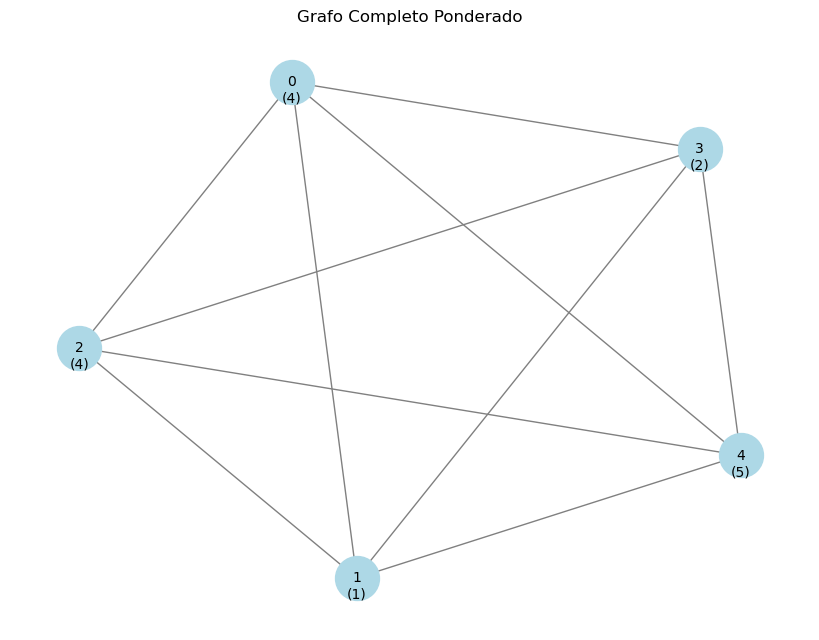

Iniciou às 2025-03-27 18:02:46.046

Com Programação Dinâmica:
Melhor caminho: [4, 0, 2, 3, 1]
Tempo de execução: 0.004002094268798828 segundos
Quantidade de estados  a serem gerados: 26
Número de entradas na tabela dinâmica: 26
Número de reusos: 30
Número de estados distintos usados:  20

Vértices escolhidos por Ana: [4, 2, 1]
Ganho de Ana: 10

Vértices escolhidos por Bob: [0, 3]
Ganho de Bob: 6

Estados Reutilizados:
(3, 4) → reutilizado 2 vezes
  Instantes de reutilização:
    - 2025-03-27 18:02:46.048
    - 2025-03-27 18:02:46.049
(2, 4) → reutilizado 2 vezes
  Instantes de reutilização:
    - 2025-03-27 18:02:46.048
    - 2025-03-27 18:02:46.049
(1, 4) → reutilizado 2 vezes
  Instantes de reutilização:
    - 2025-03-27 18:02:46.048
    - 2025-03-27 18:02:46.049
(2, 3) → reutilizado 2 vezes
  Instantes de reutilização:
    - 2025-03-27 18:02:46.048
    - 2025-03-27 18:02:46.049
(1, 3) → reutilizado 2 vezes
  Instantes de reutilização:
    - 2025-03-27 18:02:46.048
    - 2025-03-27 1

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import time
import random
import datetime

from typing import Dict, Tuple
contagem_reuso_dp = 0
estados_reusados = {}
estados_na_tabela = set()
estados_timestamps = {}


################################################ VAL(G) ######################################################

def valor(grafo: nx.Graph, pesos: Dict[int, int], profundidade=0) -> Tuple[int, list, list]:
    if not grafo.nodes:
        return 0, [], []
    melhor_valor = float('-inf')
    melhor_escolha = None
    arvore_decisao = []
    melhor_caminho = []
     
    for v in list(grafo.nodes):
        if eh_viavel(grafo, v):
            grafo_copia = grafo.copy()
            grafo_copia.remove_node(v)
            valor_subgrafo, sub_arvore_decisao, sub_melhor_caminho = valor(grafo_copia, pesos, profundidade + 1)
            valor_atual = pesos[v] - valor_subgrafo
            arvore_decisao.append((v, valor_atual, sub_arvore_decisao))
            
            if valor_atual > melhor_valor:
                melhor_valor = valor_atual
                melhor_escolha = v
                melhor_caminho = [v] + sub_melhor_caminho
    
    return melhor_valor, arvore_decisao, melhor_caminho

def valor_dp(grafo: nx.Graph, pesos: dict, memo=None, profundidade=0, history=()):
    global contagem_reuso_dp, estados_reusados, estados_na_tabela

    if memo is None:
        memo = {}

    estado = tuple(grafo.nodes)
    
    if estado in memo:
        timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S.%f")[:-3]
        contagem_reuso_dp += 1
        
        if estado not in estados_reusados:
            estados_reusados[estado] = {'count': 0, 'timestamps': []}
        
        estados_reusados[estado]['count'] += 1
        estados_reusados[estado]['timestamps'].append(timestamp)
        
        return memo[estado]

    if not grafo.nodes:
        return 0, [], []
    
    melhor_valor = float('-inf')
    melhor_caminho = []
    arvore_decisao = []
    
    for v in list(grafo.nodes):
        if eh_viavel(grafo, v):
            grafo_copia = grafo.copy()
            grafo_copia.remove_node(v)
            novo_history = history + (v,)
            valor_subgrafo, sub_arvore_decisao, sub_melhor_caminho = valor_dp(grafo_copia, pesos, memo, profundidade + 1, novo_history)
            valor_atual = pesos[v] - valor_subgrafo
            
            arvore_decisao.append((v, valor_atual, sub_arvore_decisao))
            
            if valor_atual > melhor_valor:
                melhor_valor = valor_atual
                melhor_caminho = [v] + sub_melhor_caminho
            
            if len(grafo.nodes) > 1:
                memo[estado] = (melhor_valor, arvore_decisao, melhor_caminho)
                estados_na_tabela.add(estado)
                
    return melhor_valor, arvore_decisao, melhor_caminho


def eh_viavel(grafo: nx.Graph, v: int) -> bool:
    if len(grafo.nodes) == 1:
        return True
    
    grafo_copia = grafo.copy()
    grafo_copia.remove_node(v)
    return nx.is_connected(grafo_copia) if grafo_copia.nodes else True

#######################################  BICOLORAÇÃO CAMINHO ###########################################

def bicoloracaoCaminho(grafo,pesos):
    n = len(grafo)  # Número de vértices no grafo
    colors = [-1] * n  # -1 significa que o nó ainda não foi colorido
    verticesPares = []
    verticesImpares = []
    somaPar = 0
    somaImpar = 0
    for i, v in enumerate(grafo.nodes):
        if i % 2 == 0:
            verticesPares.append(v)
            somaPar += pesos[v]
        else:
            verticesImpares.append(v)
            somaImpar += pesos[v]

    print(f"Pares: {verticesPares}")
    print(f"Impares: {verticesImpares}")
    if somaPar >= somaImpar:
        return verticesPares,somaPar
    else:
        return verticesImpares,somaImpar
        
##################################### GULOSO EM COMPLETO  #################################################


def estrategia_gulosa_completo(grafo, pesos):
    vertices = sorted(pesos.keys(), key=lambda v: pesos[v], reverse=True)  # Ordena pelos maiores pesos
    ganho_ana, ganho_bob = 0, 0
    vertices_ana, vertices_bob = [], []
    
    for i, vertice in enumerate(vertices):
        if i % 2 == 0:
            ganho_ana += pesos[vertice]
            vertices_ana.append(vertice)
        else:
            ganho_bob += pesos[vertice]
            vertices_bob.append(vertice)
    
    print("\nEstratégia Gulosa:")
    print("Vértices escolhidos por Ana:", vertices_ana)
    print("Ganho de Ana:", ganho_ana)
    print("Vértices escolhidos por Bob:", vertices_bob)
    print("Ganho de Bob:", ganho_bob)

################################### GULOSO/BICOLORAÇÃO EM CICLO ########################################################

def estrategia_gulosa_ciclo(grafo, pesos):
    melhor_escolha = None
    melhor_pontuacao = float('-inf')
    melhor_caminho = []
    
    for v in grafo.nodes:
        grafo_reduzido = grafo.copy()
        grafo_reduzido.remove_node(v)
        caminho = list(nx.dfs_preorder_nodes(grafo_reduzido))  # Transformando em caminho
        
        bob_caminho, bob_pontuacao = bicoloracaoCaminho(grafo_reduzido, pesos)
        ana_pontuacao = pesos[v]  # Ana pega apenas este vértice
        
        if ana_pontuacao > melhor_pontuacao:
            melhor_pontuacao = ana_pontuacao
            melhor_escolha = v
            melhor_caminho = bob_caminho
    
    # Ana faz a escolha ótima
    grafo_final = grafo.copy()
    grafo_final.remove_node(melhor_escolha)
    caminhoEscolhido, ganho = bicoloracaoCaminho(grafo_final, pesos)
    ganho += pesos[melhor_escolha]  # Somamos o peso do primeiro vértice escolhido por Ana
    caminhoEscolhido.insert(0, melhor_escolha)  # Ana começa com esse vértice
    
    return caminhoEscolhido, ganho
            
################################################################################################################


def plotarArvoreDeDecisao(tree, comDp = True,parent_name='G', graph=None, pos=None, level=0, x=0, width=1, counter=None):
    """Gera uma árvore de decisão organizada hierarquicamente, com identificadores únicos para nós repetidos."""
    if graph is None:
        graph = nx.DiGraph()
        pos = {parent_name: (0, 0)}  # Posição inicial da raiz
    if counter is None:
        counter = 0  # Inicializa um contador para garantir nós únicos
    
    if parent_name == 'G':
        level = 1  # Faz com que o vértice G seja a raiz
    
    num_children = len(tree)
    if num_children == 0:
        return graph, pos, counter
    
    spacing = width / max(num_children, 1)
    x_offset = x - (width / 2) + (spacing / 2)
    
    for i, (choice, value, subtree) in enumerate(tree):
        # Criando um identificador único para cada nó
        if comDp:
            node_name = f'{choice}({value})'
        else:
            node_name = f'{choice}_{counter} ({value})'
        counter += 1
        
        graph.add_edge(parent_name, node_name)
        pos[node_name] = (x_offset + i * spacing, -level)
        
        # Recursão para os subgrafos
        graph, pos, counter = plotarArvoreDeDecisao(subtree,comDp, node_name, graph, pos, level + 1, x_offset + i * spacing, spacing, counter)
    
    return graph, pos, counter

def imprimirArvoreDecisao(arvore_decisao, comDP=True):
    arvore_plotada, pos, counter = plotarArvoreDeDecisao(arvore_decisao,comDP)
    plt.figure(figsize=(16, 12))
    nx.draw(arvore_plotada, pos, with_labels=True, node_color="lightblue", width=2, font_size=10)
    plt.title("Árvore de Decisão Final com Caminhos Hierárquicos")
    plt.show()

def calcular_ganhos(melhor_caminho, pesos):
    ganho_ana = 0
    ganho_bob = 0
    vertices_ana = []
    vertices_bob = []

    for i, vertice in enumerate(melhor_caminho):
        if i % 2 == 0:
            ganho_ana += pesos[vertice]
            vertices_ana.append(vertice)
        else:
            ganho_bob += pesos[vertice]
            vertices_bob.append(vertice)

    print("\nVértices escolhidos por Ana:", vertices_ana)
    print("Ganho de Ana:", ganho_ana)
    
    print("\nVértices escolhidos por Bob:", vertices_bob)
    print("Ganho de Bob:", ganho_bob)



##============================= CRIAÇÃO E PLOT DE GRAFO =======================================##

#======================================= POLINOMIAL PARA ÁRVORES =====================================================#




#===================================================================================================================#




def plot_graph(G, pesos, title):
    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(G)  # Layout para melhor visualização
    nx.draw(G, pos, with_labels=True, node_color="lightblue", node_size=1000, font_size=10, edge_color="gray")
    
    labels = {node: f"\n\n({pesos[node]})" for node in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels, font_size=10, font_color="black")
    
    plt.title(title)
    plt.show()

def gerar_grafo_caminho(n):
    G = nx.path_graph(n)
    nos = list(G.nodes())
    random.shuffle(nos)
    pesos = {v: random.randint(1, n) for v in nos}
    plot_graph(G, pesos, "Grafo Caminho Ponderado")
    return G, pesos

def gerar_grafo_ciclo(n):
    G = nx.cycle_graph(n)
    nos = list(G.nodes())
    random.shuffle(nos)
    pesos = {v: random.randint(1, n) for v in nos}
    plot_graph(G, pesos, "Grafo Ciclo Ponderado")
    return G, pesos

def gerar_grafo_completo(n):
    G = nx.complete_graph(n)
    nos = list(G.nodes())
    random.shuffle(nos)
    pesos = {v: random.randint(1, n) for v in nos}
    plot_graph(G, pesos, "Grafo Completo Ponderado")
    return G, pesos

def criar_grafo_bipartido(m, n):
    """Cria um grafo bipartido com dois conjuntos de vértices de tamanhos m e n."""
    G = nx.Graph()
    conjunto_x = [f"X{i}" for i in range(m)]  # Conjunto X
    conjunto_y = [f"Y{i}" for i in range(n)]  # Conjunto Y
    
    G.add_nodes_from(conjunto_x, bipartite=0)
    G.add_nodes_from(conjunto_y, bipartite=1)
    
    # Adiciona arestas aleatórias entre os conjuntos
    for x in conjunto_x:
        for y in conjunto_y:
            if random.random() > 0.5:  # Probabilidade de conexão
                G.add_edge(x, y)
    
    # Atribui pesos aleatórios aos nós
    pesos = {node: random.randint(1, 10) for node in G.nodes()}
    plotar_grafo_bipartido(G, conjunto_x, conjunto_y,pesos)
    return G, pesos, conjunto_x, conjunto_y


def criar_grafo_bipartido_completo(m, n):
    """Cria um grafo bipartido completo K(m, n) com dois conjuntos de vértices de tamanhos m e n."""
    G = nx.complete_bipartite_graph(m, n)
    
    conjunto_x = [f"X{i}" for i in range(m)]  # Conjunto X
    conjunto_y = [f"Y{i}" for i in range(n)]  # Conjunto Y
    
    mapping = {i: conjunto_x[i] for i in range(m)}
    mapping.update({i + m: conjunto_y[i] for i in range(n)})
    G = nx.relabel_nodes(G, mapping)
    
    # Atribui pesos aleatórios aos nós
    pesos = {node: random.randint(1, 10) for node in G.nodes()}
    plotar_grafo_bipartido(G, conjunto_x, conjunto_y,pesos)

    return G, pesos, conjunto_x, conjunto_y

def plotar_grafo_bipartido(G, conjunto_x, conjunto_y, pesos, title="Grafo Bipartido com Pesos Aleatórios"):
    """Plota um grafo bipartido organizado, com X à esquerda e Y à direita, e exibe os pesos nos vértices."""
    plt.figure(figsize=(8, 6))
    
    pos = {}
    x_offset = -1  # X fica na esquerda
    y_offset = 1   # Y fica na direita
    
    for i, node in enumerate(conjunto_x):
        pos[node] = (x_offset, i - len(conjunto_x) / 2)  # Alinhar verticalmente

    for i, node in enumerate(conjunto_y):
        pos[node] = (y_offset, i - len(conjunto_y) / 2)  # Alinhar verticalmente

    nx.draw(G, pos, node_color="lightblue", node_size=1000, font_size=12)
    
    labels = {node: f"{node}\n({pesos[node]})" for node in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels, font_size=10, font_color="black")

    plt.title(title)
    plt.show()

def grafoSimples():
    G = nx.Graph()
    edges = [('v1', 'v2'), ('v2', 'v3'), ('v3', 'v4')]
    #edges = [('v4', 'v3'), ('v3', 'v2'), ('v2', 'v1')]

    G.add_edges_from(edges)
    weights = {'v1': 5, 'v2': 4, 'v3': 1, 'v4': 3}

    return G,weights


def arvoreCompleta(h: int):
    """Gera uma árvore completa de altura h."""
    G = nx.Graph()
    
    if h < 0:
        raise ValueError("A altura da árvore deve ser um número inteiro não negativo.")
    
    def adicionar_nos(G, parent, nivel_atual, max_nivel, contador):
        if nivel_atual > max_nivel:
            return contador
        
        filhos = [f'v{contador + i}' for i in range(2)]  # Cada nó tem dois filhos (árvore binária)
        for filho in filhos:
            G.add_edge(parent, filho)
        
        novo_contador = contador + 2
        for filho in filhos:
            novo_contador = adicionar_nos(G, filho, nivel_atual + 1, max_nivel, novo_contador)
        
        return novo_contador
    
    G.add_node("v0")  # Raiz da árvore
    adicionar_nos(G, "v0", 1, h, 1)
    
    pesos = {node: random.randint(1, 10) for node in G.nodes()}

    imprimirArvoreCompleta(G,pesos)
    return G, pesos
    



##================================== FUNÇÕES DA PD ==============================##



def imprime_estados_reusados():
    print("\nEstados Reutilizados:")
    
    if not estados_reusados:
        print("Nenhum estado foi reutilizado.")
        return
    
    for estado, info in estados_reusados.items():
        print(f"{estado} → reutilizado {info['count']} vezes")
        print("  Instantes de reutilização:")
        for timestamp in info['timestamps']:
            print(f"    - {timestamp}")


        
def imprimirTabelaPd(soTamanho =  True):
    """Imprime a tabela de programação dinâmica para análise da complexidade."""
    len(tabela_dp)
    qtdDeLinhas = 0 
    print("\n Tabela de Programação Dinâmica:")
    for estado, (resultados, _) in tabela_dp.items():
        if(soTamanho == False):
            print(f"Estado: {estado}")
        for caminho, ganho_alice, ganho_bob in resultados:
            qtdDeLinhas = qtdDeLinhas + 1
            if(soTamanho == False):
                print(f"  Caminho: {caminho} → Alice: {ganho_alice}, Bob: {ganho_bob}")

    print(f"\nTAMANHO DA TABELA: {qtdDeLinhas}" )

def imprime_estados_nao_reutilizados():
    estados_nao_reutilizados = estados_na_tabela - estados_reusados  # Diferença entre os conjuntos
    print("\nEstados NÃO reutilizados:")
    for estado in estados_nao_reutilizados:
        print(estado)
    print(f"\nTotal de estados que nunca foram reutilizados: {len(estados_nao_reutilizados)}")



def contar_estados(grafo: nx.Graph) -> int:
    estados_gerados = set()

    def explorar_estados(subgrafo: nx.Graph):
        estado = tuple(subgrafo.nodes)
        if len(estado) > 1 and estado not in estados_gerados:
            estados_gerados.add(estado)

            for v in list(subgrafo.nodes):
                if eh_viavel(subgrafo, v):  # Só remove se for viável
                    novo_grafo = subgrafo.copy()
                    novo_grafo.remove_node(v)
                    explorar_estados(novo_grafo)  # Chamada recursiva para explorar mais estados

    explorar_estados(grafo)
    return len(estados_gerados)



def imprime_tabela_dp(memo):
    print("\nTabela de Programação Dinâmica:")
    for estado, (melhor_valor, arvore_decisao, melhor_caminho) in memo.items():
        print(f"Estado: {estado}")
        print(f"  Melhor valor: {melhor_valor}")
        print(f"  Melhor caminho: {melhor_caminho}")
        
        if estado in estados_reusados:
            print(f"  Reutilizado {estados_reusados[estado]['count']} vezes")
            print(f"  Instantes de reutilização: {estados_reusados[estado]['timestamps']}")
        else:
            print("  Nunca reutilizado")
        print("-------------------------")

################################################################################################################

def mainDP(grafo, pesos):
    inicio_tempo = time.time()
    memo = {}
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S.%f")[:-3]  # Mantém milissegundos
  # Captura o instante de reutilização
    print(f"Iniciou às {timestamp}")
    melhor_valor_dp, arvore_decisao_dp, melhor_caminho_dp = valor_dp(grafo, pesos, memo)
    fim_tempo = time.time()
    print("\nCom Programação Dinâmica:")
    print("Melhor caminho:", melhor_caminho_dp)
    print("Tempo de execução:", fim_tempo - inicio_tempo, "segundos")
    quantidade_estados = contar_estados(grafo)
    print("Quantidade de estados  a serem gerados:", quantidade_estados)
    print("Número de entradas na tabela dinâmica:", len(memo))
    print("Número de reusos:", contagem_reuso_dp)
    print("Número de estados distintos usados: ",len(estados_reusados))
    calcular_ganhos(melhor_caminho_dp, pesos)
    imprime_estados_reusados()
    #imprime_estados_nao_reutilizados()
    imprime_tabela_dp(memo)
    #imprimirArvoreDecisao(arvore_decisao_dp)
    
    
def mainSemDp(grafo, pesos):
    inicio_tempo = time.time()
    melhor_valor, arvore_decisao, melhor_caminho = valor(grafo, pesos)
    fim_tempo = time.time()
    print("Sem Programação Dinâmica:")
    print("Melhor caminho:", melhor_caminho)
    print("Tempo de execução:", fim_tempo - inicio_tempo, "segundos")
    calcular_ganhos(melhor_caminho, pesos)
    imprimirArvoreDecisao(arvore_decisao,False)

def mainBicoloracaoCaminho(grafo,pesos):
    inicio_tempo = time.time()
    caminhoEscolhido,ganho = bicoloracaoCaminho(grafo,pesos)
    fim_tempo = time.time()
    print("\n ======== Bicoloração em Caminho: ==========\n")
    print(f"Sequencia vencedora da Ana: {caminhoEscolhido} : Peso = {ganho} ")
    print("Tempo de execução:", fim_tempo - inicio_tempo, "segundos")

def mainGulosoCompleto(grafo,pesos):
    inicio_tempo = time.time()
    print("\n ======== GULOSO EM COMPLETO: ==========\n")
    estrategia_gulosa_completo(grafo,pesos)
    fim_tempo = time.time()
    print("Tempo de execução:", fim_tempo - inicio_tempo, "segundos")


def mainGulosoBicoloridoCiclo(grafo,pesos):
    inicio_tempo = time.time()
    caminhoEscolhido, ganho = estrategia_gulosa_ciclo(grafo, pesos)
    fim_tempo = time.time()
    print("\n ======== Bicoloração em Caminho: ==========\n")
    print(f"Sequencia vencedora da Ana: {caminhoEscolhido} : Peso = {ganho} ")
    print("Tempo de execução:", fim_tempo - inicio_tempo, "segundos")




def main():
    m, n = 2,4
    altura = 4
    
    #grafo, pesos = gerar_grafo_ciclo(12)      # Gera um ciclo de 5 nós
    grafo, pesos = gerar_grafo_completo(5)   # Gera um grafo completo de 6 nós
    #grafo, pesos = gerar_grafo_caminho(20)    # Gera um caminho de 4 nós
    #grafo, pesos, conjunto_x, conjunto_y = criar_grafo_bipartido(m, n)
    #grafo, pesos, conjunto_x, conjunto_y = criar_grafo_bipartido_completo(m, n)
    #grafo, pesos = grafoSimples()
    #grafo, pesos = arvoreCompleta(altura)


    mainDP( grafo, pesos)
    #mainSemDp( grafo, pesos)

    #mainBicoloracaoCaminho( grafo, pesos)
    mainGulosoCompleto(grafo,pesos)
    #mainGulosoBicoloridoCiclo(grafo,pesos)
main()